In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import display, HTML

In [152]:
# Set seaborn style for better visuals
sns.set(style="whitegrid")
%matplotlib inline

# Function to parse metric with mean and std
def parse_metric(metric_str):
    if not metric_str or pd.isna(metric_str):
        return None, None
    match = re.match(r'([\d.]+)\s*\(±([\d.]+)\)', metric_str)
    if match:
        return float(match.group(1)), float(match.group(2))
    return float(metric_str), None


# Load the data
df = pd.read_csv('Research Data - Summary.csv')

In [153]:
# Parse metrics into mean and std columns
df[['Accuracy_mean', 'Accuracy_std']] = df['Accuracy'].apply(lambda x: pd.Series(parse_metric(x)))
df[['F1_mean', 'F1_std']] = df['F1'].apply(lambda x: pd.Series(parse_metric(x)))
df[['Epochs_mean', 'Epochs_std']] = df['Epochs'].apply(lambda x: pd.Series(parse_metric(x)))

In [154]:

df = df.rename(columns={
    'Base_Model_Class': 'Base_Model_Classes',
    'FT/Direct_Classes': 'FT_Direct_Classes',
    'FT/T_Instance_per_class': 'Instances_per_class'
})

# Convert 'Overlapping' to boolean for consistency
df['Overlapping'] = df['Overlapping'].map({'Yes': True, 'No': False})

In [155]:
scrollable_table = f"""
<div style="height: 300px; overflow: auto;">
{df.to_html()}
</div>
"""
display(HTML(scrollable_table))

,Model,Accuracy,F1,Epochs,Base_Model_Classes,FT_Direct_Classes,Instances_per_class,Model_Type,Overlapping,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Epochs_mean,Epochs_std
0,240 Class ISL Base Model,0.6079,NaN,NaN,240.0,NaN,NaN,BASE,False,0.6079,NaN,NaN,NaN,NaN,NaN
1,200 Class ISL Base Model,0.6247,NaN,NaN,200.0,NaN,NaN,BASE,False,0.6247,NaN,NaN,NaN,NaN,NaN
2,160 Class ISL Base Model,0.6478,NaN,NaN,160.0,NaN,NaN,BASE,False,0.6478,NaN,NaN,NaN,NaN,NaN
3,120 Class ISL Base Model,0.6173,NaN,NaN,120.0,NaN,NaN,BASE,False,0.6173,NaN,NaN,NaN,NaN,NaN
4,80 Class ISL Base Model,0.6468,NaN,NaN,80.0,NaN,NaN,BASE,False,0.6468,NaN,NaN,NaN,NaN,NaN
5,80 Class ISL Base Model (Overlapping class with SSL Dataset),0.6206,NaN,NaN,80.0,NaN,NaN,BASE,True,0.6206,NaN,NaN,NaN,NaN,NaN
6,240 Class ISL Base Model Finetuned with 64 Class SSL- 6 Instance per Class (5 runs avg),0.7746 (±0.0129),0.7663 (±0.0167),83.8000 (±9.9880),240.0,64.0,6.0,FINETUNED,False,0.7746,0.0129,0.7663,0.0167,83.8,9.9880
7,200 Class ISL Base Model Finetuned with 64 Class SSL- 6 Instance Per Class (5 runs avg),0.7272 (±0.0089),0.7213 (±0.0095),62.0000 (±7.6942),200.0,64.0,6.0,FINETUNED,False,0.7272,0.0089,0.7213,0.0095,62.0,7.6942
8,160 Class ISL Base Model Finetuned with 64 Class SSL- 6 Instance Per Class (5 runs avg),0.7629 (±0.0310),0.7552 (±0.0326),75.4000 (±10.8922),160.0,64.0,6.0,FINETUNED,False,0.7629,0.0310,0.7552,0.0326,75.4,10.8922
9,120 Class ISL Base Model Finetuned with 64 Class SSL- 6 Instance Per Class (5 runs avg),0.7067 (±0.0104),0.6972 (±0.0100),82.2000 (±12.3839),120.0,64.0,6.0,FINETUNED,False,0.7067,0.0104,0.6972,0.0100,82.2,12.3839


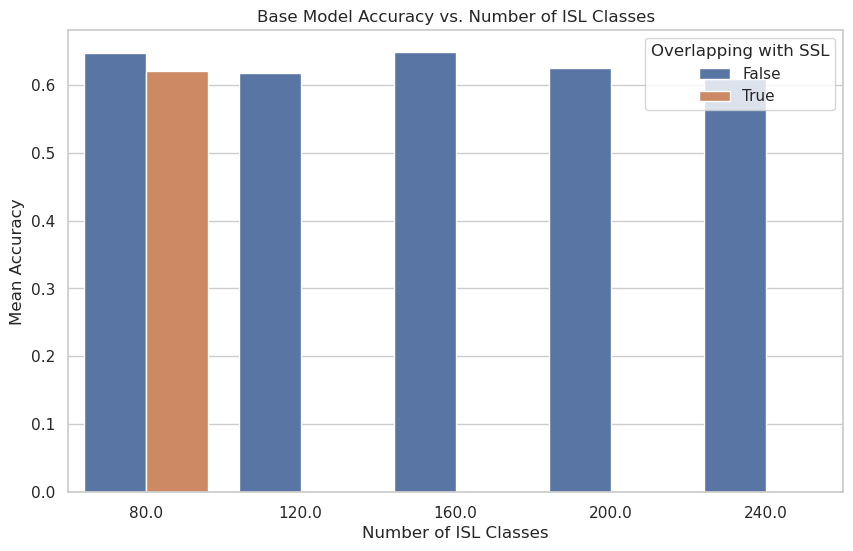

In [156]:
plt.figure(figsize=(10, 6))
base_df = df[df['Model_Type'] == 'BASE'].sort_values('Base_Model_Classes')
sns.barplot(x='Base_Model_Classes', y='Accuracy_mean', hue='Overlapping', data=base_df)
plt.title('Base Model Accuracy vs. Number of ISL Classes')
plt.xlabel('Number of ISL Classes')
plt.ylabel('Mean Accuracy')
plt.legend(title='Overlapping with SSL')
plt.show()

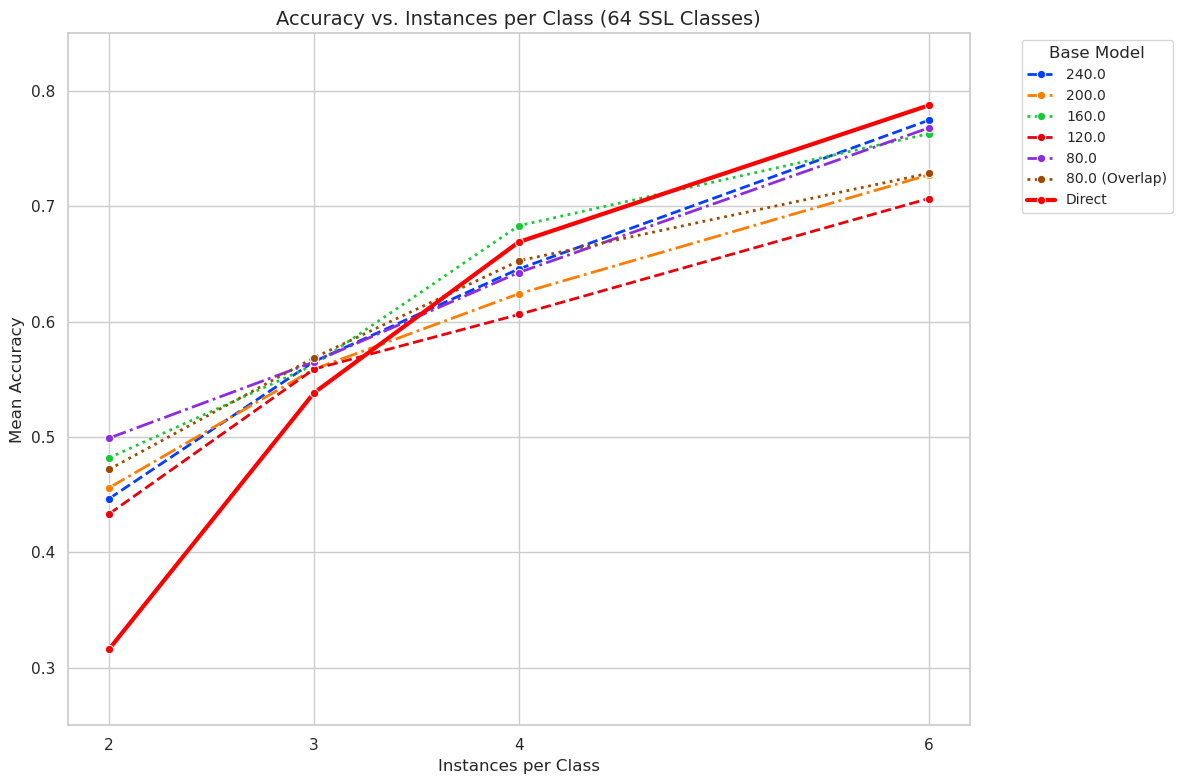

In [157]:

plt.figure(figsize=(12, 8))

# Filter data for 64 classes
ft_64 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 64)]
direct_64 = df[(df['Model_Type'] == 'DIRECT') & (df['FT_Direct_Classes'] == 64)]
combined = pd.concat([ft_64, direct_64])

# Create Base_Model_Label
combined['Base_Model_Label'] = combined.apply(
    lambda row: f"{row['Base_Model_Classes']}{' (Overlap)' if row['Overlapping'] else ''}"
    if row['Model_Type'] == 'FINETUNED' else 'Direct', axis=1)

# Filter for specific x-axis values (2, 3, 4, 6)
combined = combined[combined['Instances_per_class'].isin([2, 3, 4, 6])]

# Define custom styles and colors
unique_labels = combined['Base_Model_Label'].unique()
palette = sns.color_palette("bright", len(unique_labels))  # Distinct colors
styles = ['--', '-.', ':', '--', '-.', ':', '-']  # Line styles for Fine-tuned + solid for Direct
colors = {label: palette[i] for i, label in enumerate(unique_labels)}
colors['Direct'] = '#FF0000'  # Red for Direct model

# Plot with custom styles
for label in unique_labels:
    subset = combined[combined['Base_Model_Label'] == label]
    if label == 'Direct':
        # Highlight Direct with solid, bold line
        sns.lineplot(x='Instances_per_class', y='Accuracy_mean', data=subset,
                     label=label, color=colors[label], linestyle='-', linewidth=3, marker='o')
    else:
        # Fine-tuned models with dashed/dotted lines
        style_idx = list(unique_labels).index(label) % (len(styles) - 1)  # Avoid solid line
        sns.lineplot(x='Instances_per_class', y='Accuracy_mean', data=subset,
                     label=label, color=colors[label], linestyle=styles[style_idx], linewidth=2, marker='o')

# Customize plot
plt.title('Accuracy vs. Instances per Class (64 SSL Classes)', fontsize=14)
plt.xlabel('Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xticks([2, 3, 4, 6])  # Explicitly set x-axis ticks
plt.legend(title='Base Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.ylim((0.25, 0.85))
plt.tight_layout()
plt.show()

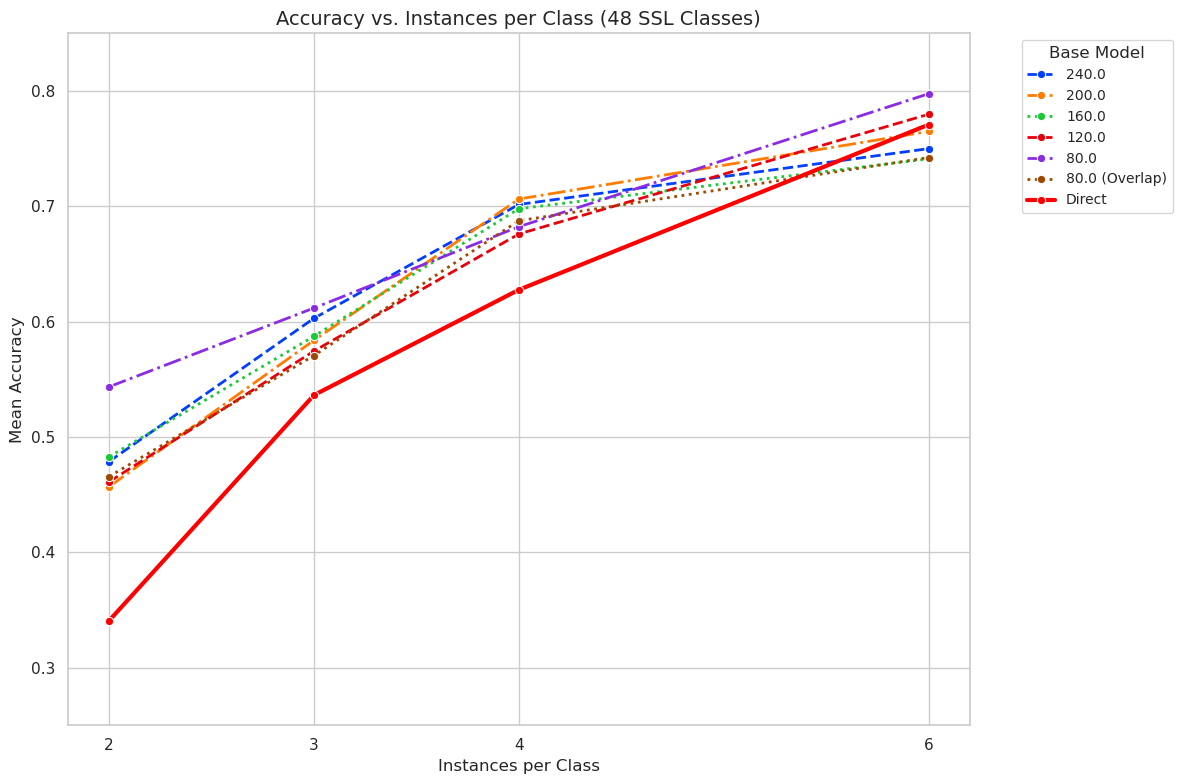

In [158]:
plt.figure(figsize=(12, 8))

# Filter data for 64 classes
ft_48 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 48)]
direct_48 = df[(df['Model_Type'] == 'DIRECT') & (df['FT_Direct_Classes'] == 48)]
combined = pd.concat([ft_48, direct_48])

# Create Base_Model_Label
combined['Base_Model_Label'] = combined.apply(
    lambda row: f"{row['Base_Model_Classes']}{' (Overlap)' if row['Overlapping'] else ''}"
    if row['Model_Type'] == 'FINETUNED' else 'Direct', axis=1)

# Filter for specific x-axis values (2, 3, 4, 6)
combined = combined[combined['Instances_per_class'].isin([2, 3, 4, 6])]

# Define custom styles and colors
unique_labels = combined['Base_Model_Label'].unique()
palette = sns.color_palette("bright", len(unique_labels))  # Distinct colors
styles = ['--', '-.', ':', '--', '-.', ':', '-']  # Line styles for Fine-tuned + solid for Direct
colors = {label: palette[i] for i, label in enumerate(unique_labels)}
colors['Direct'] = '#FF0000'  # Red for Direct model

# Plot with custom styles
for label in unique_labels:
    subset = combined[combined['Base_Model_Label'] == label]
    if label == 'Direct':
        # Highlight Direct with solid, bold line
        sns.lineplot(x='Instances_per_class', y='Accuracy_mean', data=subset,
                     label=label, color=colors[label], linestyle='-', linewidth=3, marker='o')
    else:
        # Fine-tuned models with dashed/dotted lines
        style_idx = list(unique_labels).index(label) % (len(styles) - 1)  # Avoid solid line
        sns.lineplot(x='Instances_per_class', y='Accuracy_mean', data=subset,
                     label=label, color=colors[label], linestyle=styles[style_idx], linewidth=2, marker='o')

# Customize plot
plt.title('Accuracy vs. Instances per Class (48 SSL Classes)', fontsize=14)
plt.xlabel('Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xticks([2, 3, 4, 6])  # Explicitly set x-axis ticks
plt.legend(title='Base Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.ylim((0.25, 0.85))
plt.tight_layout()
plt.show()

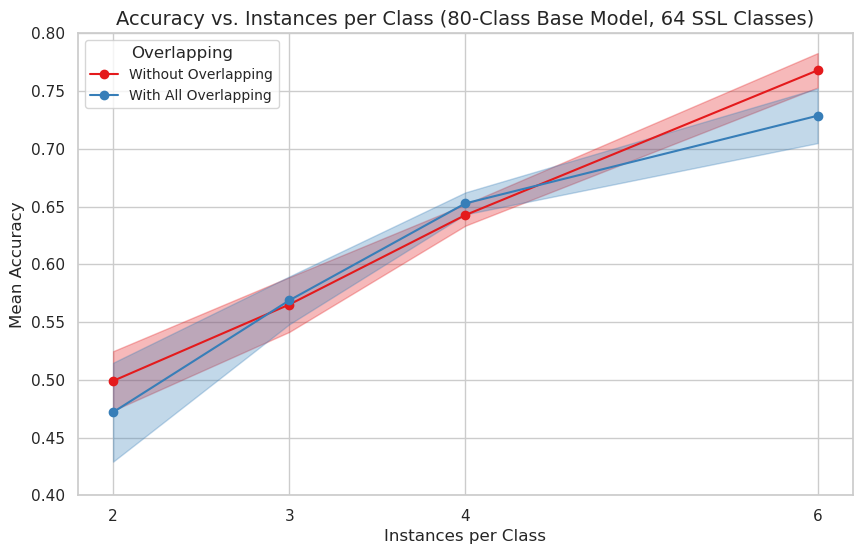

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Filter data
ft_80_64 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 64) & (df['Base_Model_Classes'] == 80)]

# Define color palette
palette = sns.color_palette('Set1', n_colors=2)
overlap_categories = ft_80_64['Overlapping'].unique()

# Plot each line + shaded std
for i, overlap in enumerate(overlap_categories):
    sub_df = ft_80_64[ft_80_64['Overlapping'] == overlap].sort_values('Instances_per_class')
    plt.plot(sub_df['Instances_per_class'], sub_df['Accuracy_mean'],
             label='With All Overlapping' if overlap else 'Without Overlapping',
             color=palette[i], marker='o')
    
    # Add shaded standard deviation
    plt.fill_between(sub_df['Instances_per_class'],
                     sub_df['Accuracy_mean'] - sub_df['Accuracy_std'],
                     sub_df['Accuracy_mean'] + sub_df['Accuracy_std'],
                     alpha=0.3, color=palette[i])

# Customize plot
plt.title('Accuracy vs. Instances per Class (80-Class Base Model, 64 SSL Classes)', fontsize=14)
plt.xlabel('Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xticks([2, 3, 4, 6])
plt.ylim((0.4, 0.8))

# Add legend
plt.legend(title='Overlapping', title_fontsize=12, fontsize=10)

plt.show()


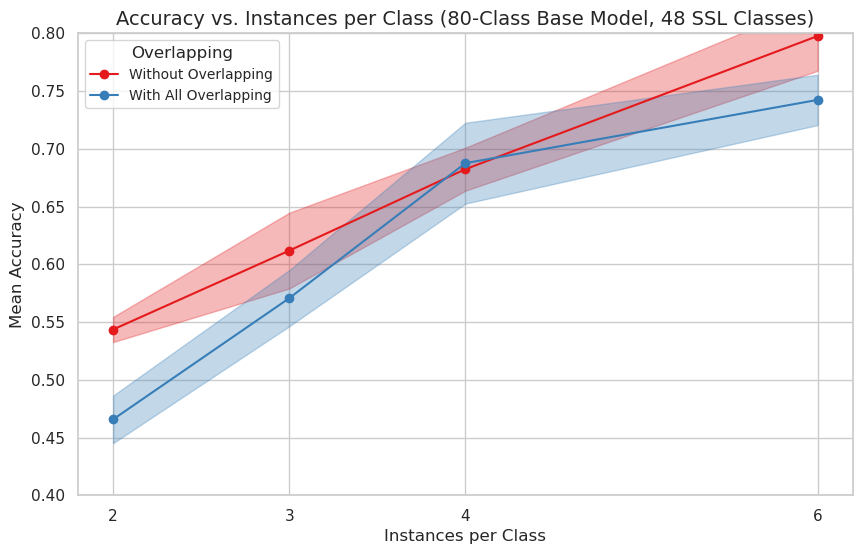

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Filter data
ft_80_64 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 48) & (df['Base_Model_Classes'] == 80)]

# Define color palette
palette = sns.color_palette('Set1', n_colors=2)
overlap_categories = ft_80_64['Overlapping'].unique()

# Plot each line + shaded std
for i, overlap in enumerate(overlap_categories):
    sub_df = ft_80_64[ft_80_64['Overlapping'] == overlap].sort_values('Instances_per_class')
    plt.plot(sub_df['Instances_per_class'], sub_df['Accuracy_mean'],
             label='With All Overlapping' if overlap else 'Without Overlapping',
             color=palette[i], marker='o')
    
    # Add shaded standard deviation
    plt.fill_between(sub_df['Instances_per_class'],
                     sub_df['Accuracy_mean'] - sub_df['Accuracy_std'],
                     sub_df['Accuracy_mean'] + sub_df['Accuracy_std'],
                     alpha=0.3, color=palette[i])

# Customize plot
plt.title('Accuracy vs. Instances per Class (80-Class Base Model, 48 SSL Classes)', fontsize=14)
plt.xlabel('Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xticks([2, 3, 4, 6])
plt.ylim((0.4, 0.8))

# Add legend
plt.legend(title='Overlapping', title_fontsize=12, fontsize=10)

plt.show()


/tmp/ipykernel_6541/3278620797.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ft_64['Model_Instance_Label'] = ft_64.apply(
/tmp/ipykernel_6541/3278620797.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ft_64['Base_Model_Group'] = ft_64.apply(


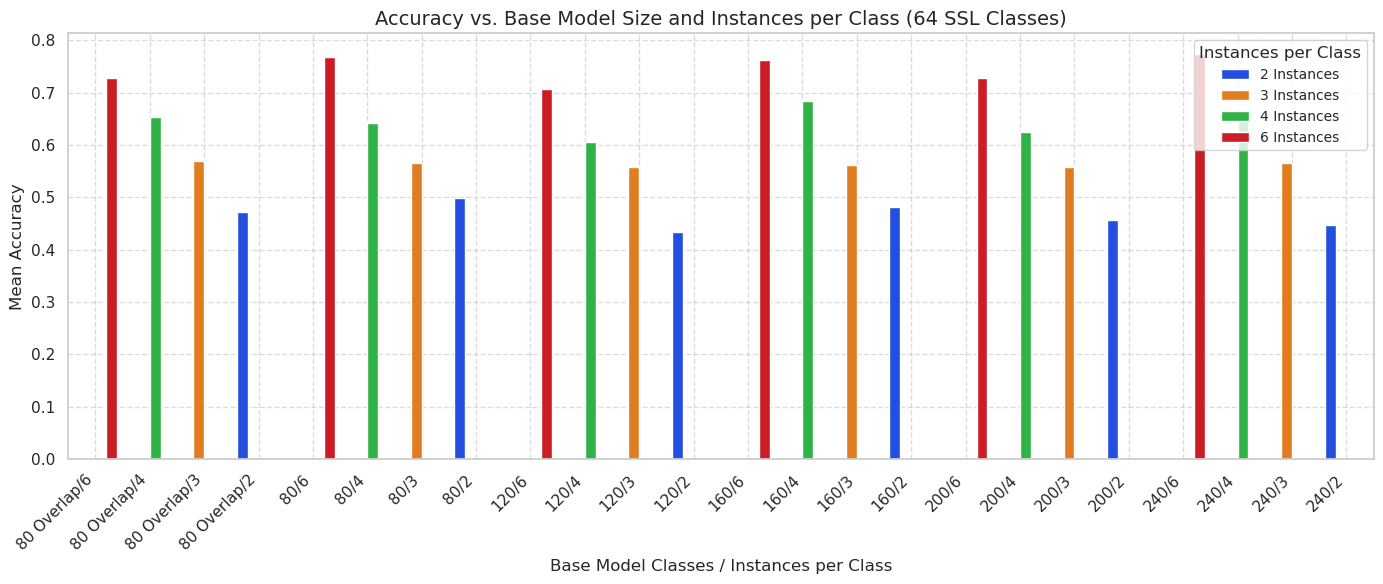

In [210]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Filter data: Fine-tuned models with 64 SSL classes
ft_64 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 64)]

# Create a new column for x-axis labels
ft_64['Model_Instance_Label'] = ft_64.apply(
    lambda row: f"{int(row['Base_Model_Classes'])}{' Overlap' if row['Overlapping'] else ''}/{int(row['Instances_per_class'])}",
    axis=1
)

# Create a new column for grouping by Base_Model_Classes and Overlapping
ft_64['Base_Model_Group'] = ft_64.apply(
    lambda row: f"{int(row['Base_Model_Classes'])}{' Overlap' if row['Overlapping'] else ''}",
    axis=1
)

# Sort the data for proper x-axis ordering
ft_64 = ft_64.sort_values(
    by=['Base_Model_Classes', 'Overlapping', 'Instances_per_class'],
    ascending=[True, False, False]
)

# Create a numerical index for plotting
ft_64['Plot_Index'] = range(len(ft_64))

# Plot: Bar plot with x as Plot_Index and hue as Instances_per_class
ax = sns.barplot(x='Plot_Index', y='Accuracy_mean', hue='Instances_per_class',
                 palette='bright', data=ft_64)

# Calculate the positions for x-axis labels to align with bar groups
unique_groups = ft_64['Base_Model_Group'].unique()
num_hues = len(ft_64['Instances_per_class'].unique())  # 4 instances: 6, 4, 3, 2
label_positions = []
group_labels = []
current_pos = 0
for group in unique_groups:
    # Get the data for this group
    group_data = ft_64[ft_64['Base_Model_Group'] == group]
    num_bars_in_group = len(group_data)
    # Center the labels under the group
    for i in range(num_bars_in_group):
        label_positions.append(current_pos + i)
    # Add the labels for this group
    group_labels.extend(group_data['Model_Instance_Label'].values)
    current_pos += num_bars_in_group

# Set the new tick positions and labels
ax.set_xticks(label_positions)
ax.set_xticklabels(group_labels, rotation=45, ha='right')

# Customize plot
plt.title('Accuracy vs. Base Model Size and Instances per Class (64 SSL Classes)', fontsize=14)
plt.xlabel('Base Model Classes / Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)

# Fix legend labels
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['2 Instances', '3 Instances', '4 Instances', '6 Instances'],
           title='Instances per Class', title_fontsize=12, fontsize=10)

# Add grid for readability
plt.grid(True, linestyle='--', alpha=0.7)

# Tight layout to prevent label cutoff
plt.tight_layout()

plt.show()

/tmp/ipykernel_6541/164945329.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ft_64['Model_Instance_Label'] = ft_64.apply(
/tmp/ipykernel_6541/164945329.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ft_64['Base_Model_Group'] = ft_64.apply(


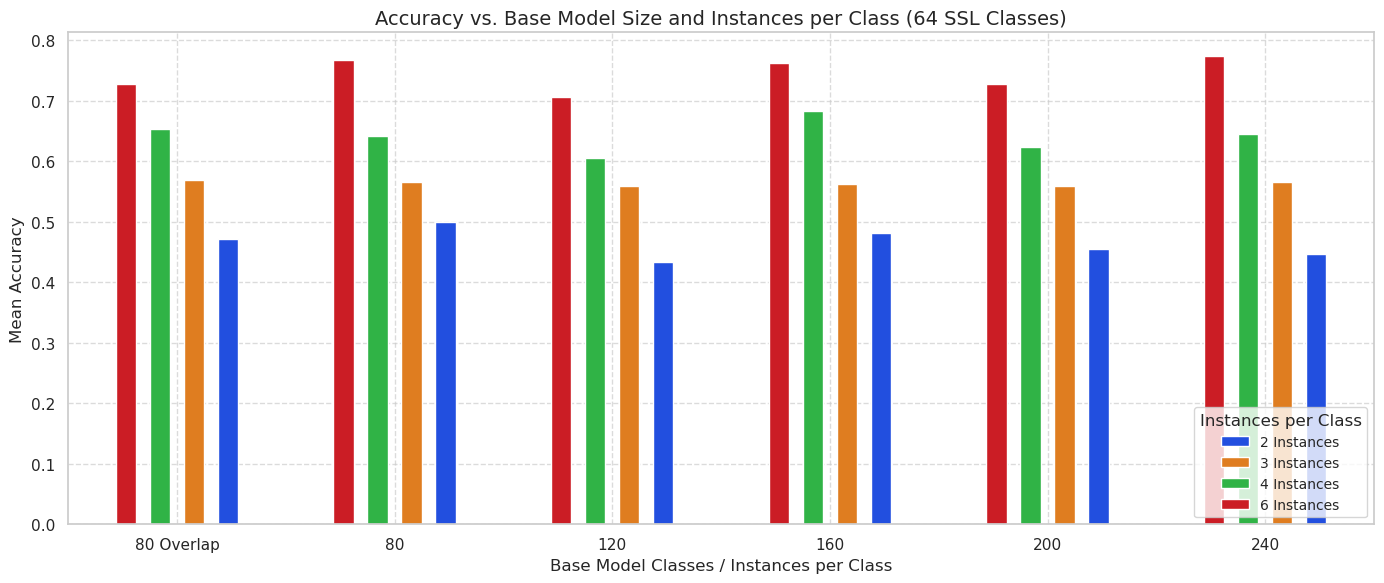

In [242]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Filter data: Fine-tuned models with 64 SSL classes
ft_64 = df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 64)]

# Create new columns for grouping and labels
ft_64['Model_Instance_Label'] = ft_64.apply(
    lambda row: f"{int(row['Base_Model_Classes'])}{' Overlap' if row['Overlapping'] else ''}/{int(row['Instances_per_class'])}",
    axis=1
)
ft_64['Base_Model_Group'] = ft_64.apply(
    lambda row: f"{int(row['Base_Model_Classes'])}{' Overlap' if row['Overlapping'] else ''}",
    axis=1
)

# Sort for correct plotting order
ft_64 = ft_64.sort_values(
    by=['Base_Model_Classes', 'Overlapping', 'Instances_per_class'],
    ascending=[True, False, False]
)

# Create plot index
ft_64['Plot_Index'] = range(len(ft_64))

# Plot
ax = sns.barplot(
    x='Plot_Index',
    y='Accuracy_mean',
    hue='Instances_per_class',
    palette='bright',
    data=ft_64,
    width=1.5
)

# Calculate the positions for each bar to add error bars
# num_hues = len(ft_64['Instances_per_class'].unique())  # 4 instances: 6, 4, 3, 2
# total_width = 1.5  # Total width of the group
# bar_width = total_width / num_hues  # Width of each bar within the group
# bar_positions = []
# current_pos = 0
# for group, group_df in ft_64.groupby('Base_Model_Group'):
#     num_bars_in_group = len(group_df)
#     # Calculate the starting position of the group
#     group_start = current_pos - (total_width / 2)
#     # Calculate the center position of each bar within the group
#     for i in range(num_bars_in_group):
#         # The offset for each hue: evenly spaced within the total_width
#         bar_center = group_start + (i + 0.5) * bar_width
#         bar_positions.append(bar_center)
#     current_pos += num_bars_in_group

# Add error bars using Accuracy_std
means = ft_64['Accuracy_mean'].values
stds = ft_64['Accuracy_std'].values
# plt.errorbar(x=bar_positions, y=means, yerr=stds, fmt='none', c='black', capsize=3, capthick=1)

# Fix label alignment: center each group
group_centers = []
group_labels = []
for group, group_df in ft_64.groupby('Base_Model_Group'):
    indices = group_df['Plot_Index'].tolist()
    center = sum(indices) / len(indices)
    group_centers.append(center)
    group_labels.append(group)

# Set only one label per group, centered
ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels, ha='center')

# Customize plot
plt.title('Accuracy vs. Base Model Size and Instances per Class (64 SSL Classes)', fontsize=14)
plt.xlabel('Base Model Classes / Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)

# Fix legend labels
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['2 Instances', '3 Instances', '4 Instances', '6 Instances'],
           title='Instances per Class', title_fontsize=12, fontsize=10, loc='lower right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6541/628326799.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ft_48['Model_Instance_Label'] = ft_48.apply(
/tmp/ipykernel_6541/628326799.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ft_48['Base_Model_Group'] = ft_48.apply(


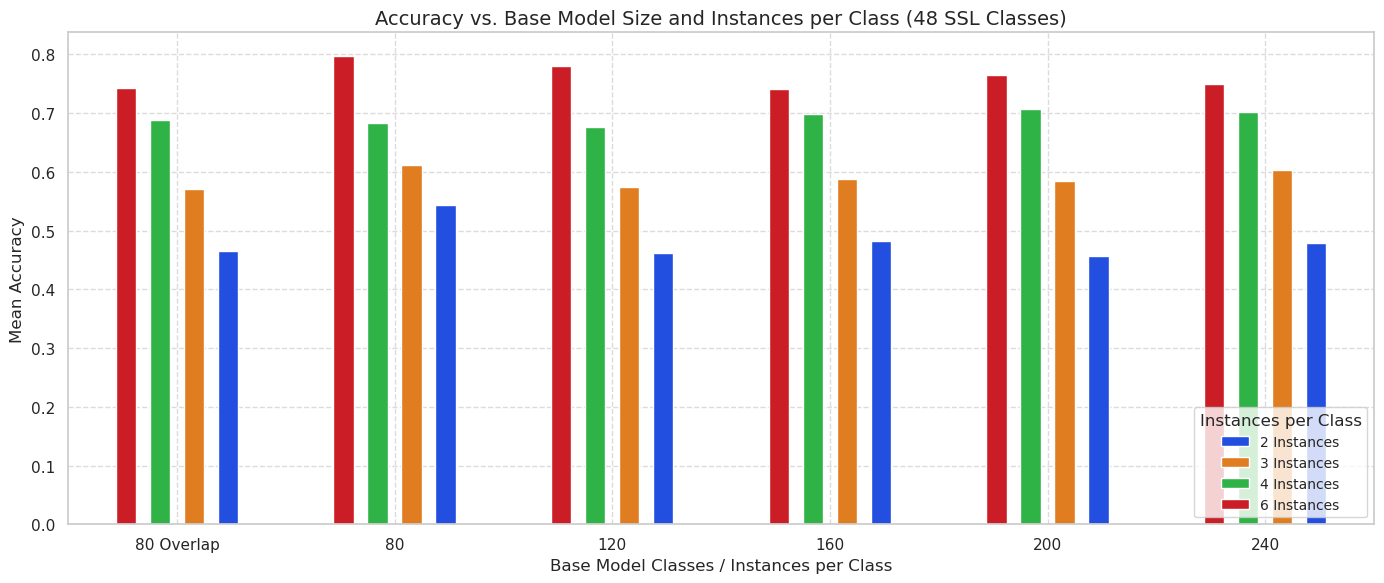

In [243]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Filter data: Fine-tuned models with 64 SSL classes
ft_48= df[(df['Model_Type'] == 'FINETUNED') & (df['FT_Direct_Classes'] == 48)]

# Create new columns for grouping and labels
ft_48['Model_Instance_Label'] = ft_48.apply(
    lambda row: f"{int(row['Base_Model_Classes'])}{' Overlap' if row['Overlapping'] else ''}/{int(row['Instances_per_class'])}",
    axis=1
)
ft_48['Base_Model_Group'] = ft_48.apply(
    lambda row: f"{int(row['Base_Model_Classes'])}{' Overlap' if row['Overlapping'] else ''}",
    axis=1
)

# Sort for correct plotting order
ft_48 = ft_48.sort_values(
    by=['Base_Model_Classes', 'Overlapping', 'Instances_per_class'],
    ascending=[True, False, False]
)

# Create plot index
ft_48['Plot_Index'] = range(len(ft_48))

# Plot
ax = sns.barplot(
    x='Plot_Index',
    y='Accuracy_mean',
    hue='Instances_per_class',
    palette='bright',
    data=ft_48,
    width=1.5
)

# Calculate the positions for each bar to add error bars
# num_hues = len(ft_64['Instances_per_class'].unique())  # 4 instances: 6, 4, 3, 2
# total_width = 1.5  # Total width of the group
# bar_width = total_width / num_hues  # Width of each bar within the group
# bar_positions = []
# current_pos = 0
# for group, group_df in ft_64.groupby('Base_Model_Group'):
#     num_bars_in_group = len(group_df)
#     # Calculate the starting position of the group
#     group_start = current_pos - (total_width / 2)
#     # Calculate the center position of each bar within the group
#     for i in range(num_bars_in_group):
#         # The offset for each hue: evenly spaced within the total_width
#         bar_center = group_start + (i + 0.5) * bar_width
#         bar_positions.append(bar_center)
#     current_pos += num_bars_in_group

# Add error bars using Accuracy_std
means = ft_48['Accuracy_mean'].values
stds = ft_48['Accuracy_std'].values
# plt.errorbar(x=bar_positions, y=means, yerr=stds, fmt='none', c='black', capsize=3, capthick=1)

# Fix label alignment: center each group
group_centers = []
group_labels = []
for group, group_df in ft_48.groupby('Base_Model_Group'):
    indices = group_df['Plot_Index'].tolist()
    center = sum(indices) / len(indices)
    group_centers.append(center)
    group_labels.append(group)

# Set only one label per group, centered
ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels, ha='center')

# Customize plot
plt.title('Accuracy vs. Base Model Size and Instances per Class (48 SSL Classes)', fontsize=14)
plt.xlabel('Base Model Classes / Instances per Class', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)

# Fix legend labels
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['2 Instances', '3 Instances', '4 Instances', '6 Instances'],
           title='Instances per Class', title_fontsize=12, fontsize=10, loc='lower right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

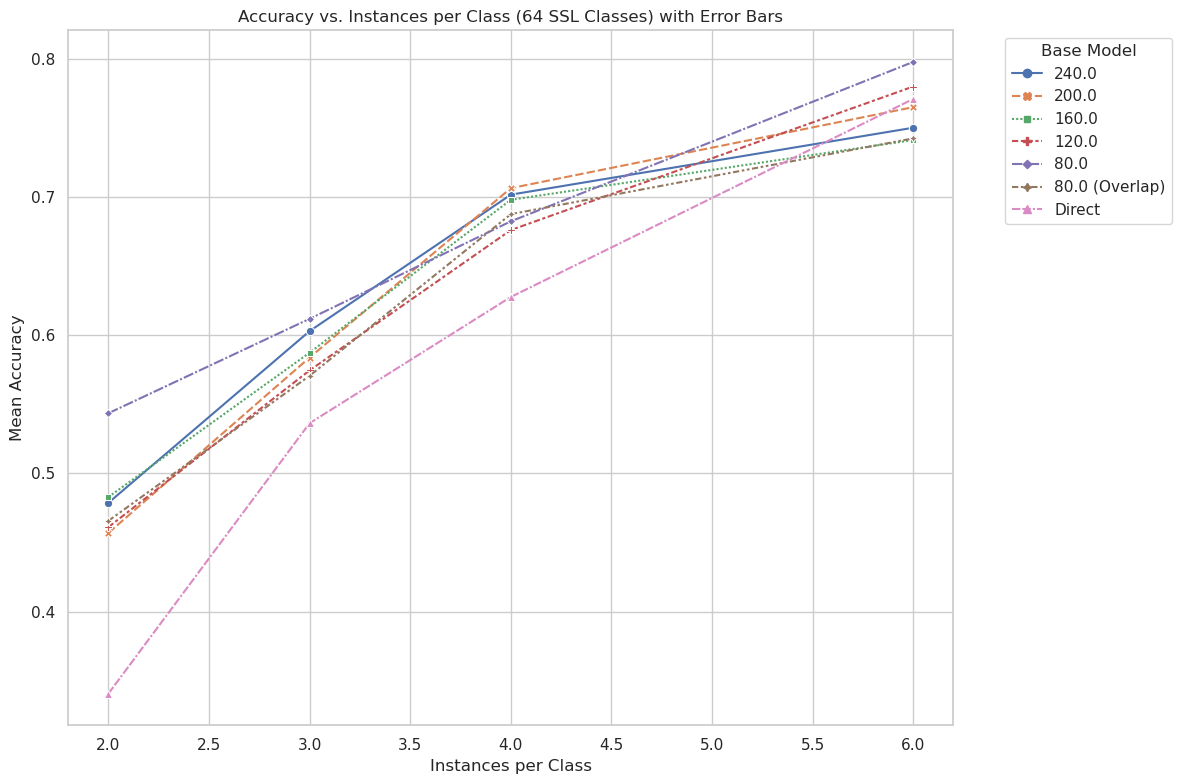

In [244]:
# Example for Plot 2 with error bars
plt.figure(figsize=(12, 8))
sns.lineplot(x='Instances_per_class', y='Accuracy_mean', hue='Base_Model_Label', style='Base_Model_Label',
             markers=True, errorbar='sd', data=combined)
plt.title('Accuracy vs. Instances per Class (64 SSL Classes) with Error Bars')
plt.xlabel('Instances per Class')
plt.ylabel('Mean Accuracy')
plt.legend(title='Base Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()